## Environment setup

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that.

In [ ]:
!nvidia-smi

### Install dependencies

Installs RF-DETR version 1.2.1 or higher (which includes the new Nano, Small, and Medium checkpoints), along with Supervision for benchmarking and Roboflow for pulling datasets and uploading models to the Roboflow platform.

In [ ]:
!pip install -q rfdetr==1.2.1 supervision==0.26.1 roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 7.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.8/372.8 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [17]:
import os
from zipfile import ZipFile

In [2]:
path = os.getcwd()
print(path)

d:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Model_Code\RF-DETR


In [ ]:
# Create the directory if it doesn't exist
extract_dir = "data"
os.makedirs(extract_dir, exist_ok=True)

with ZipFile("Glass Defect Detection.v3i.coco.zip", "r") as data_set:
    data_set.extractall(extract_dir)

In [18]:
DATA_YAML = "data/config.yaml"
data_set_dir = "D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluating-Object-Detection-Models/Coding/Datasets/Dataset_roboflow_jars/Glass Defect Detection.v3i.coco"

## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [19]:
from rfdetr import RFDETRNano

model = RFDETRNano()

rf-detr-nano.pth: 100%|██████████| 349M/349M [00:09<00:00, 37.1MiB/s] 


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


In [ ]:
model.train(dataset_dir=data_set_dir, epochs=100, batch_size=4, grad_accum_steps=4)

reinitializing your detection head with 3 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=3, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-nano.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=2, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=

RuntimeError: Inference tensors cannot be saved for backward. To work around you can make a clone to get a normal tensor and use it in autograd.

In [ ]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [ ]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [ ]:
cleanup_gpu_memory(model, verbose=True)

We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRMedium` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [23]:
model = RFDETRNano(pretrain_weights="D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluating-Object-Detection-Models/Coding/Model_Training/Dataset_Roboflow/RF-DETR/glass_defect_detection_coco_results_1/kaggle/working/output/checkpoint_best_total.pth")
model.optimize_for_inference()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 2 classes, but your model has 90 classes
reinitializing detection head with 2 classes


Loading pretrain weights


In [24]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{data_set_dir}/test",
    annotations_path=f"{data_set_dir}/test/_annotations.coco.json",
)

In [25]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision
from PIL import Image
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 173/173 [00:14<00:00, 11.59it/s]


In [26]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.595
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.841
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.557
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.232
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.337
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = 0.947


## Run Inference with Fine-tuned RF-DETR Model

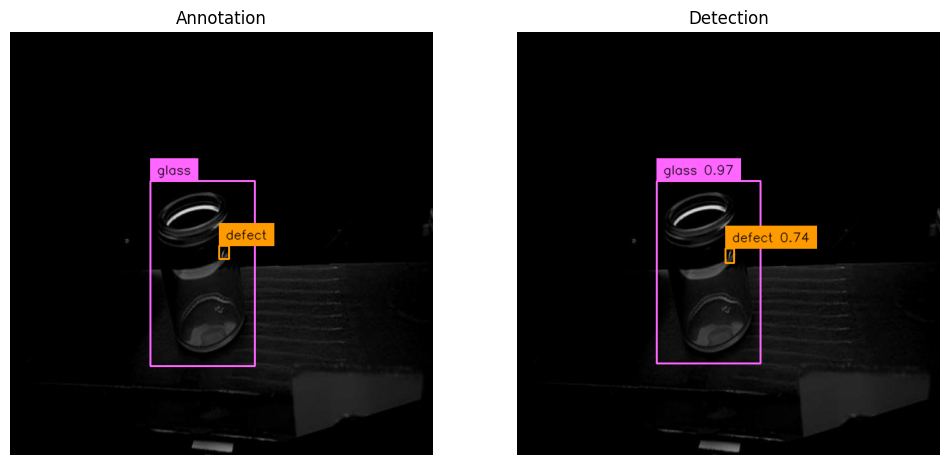

In [27]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

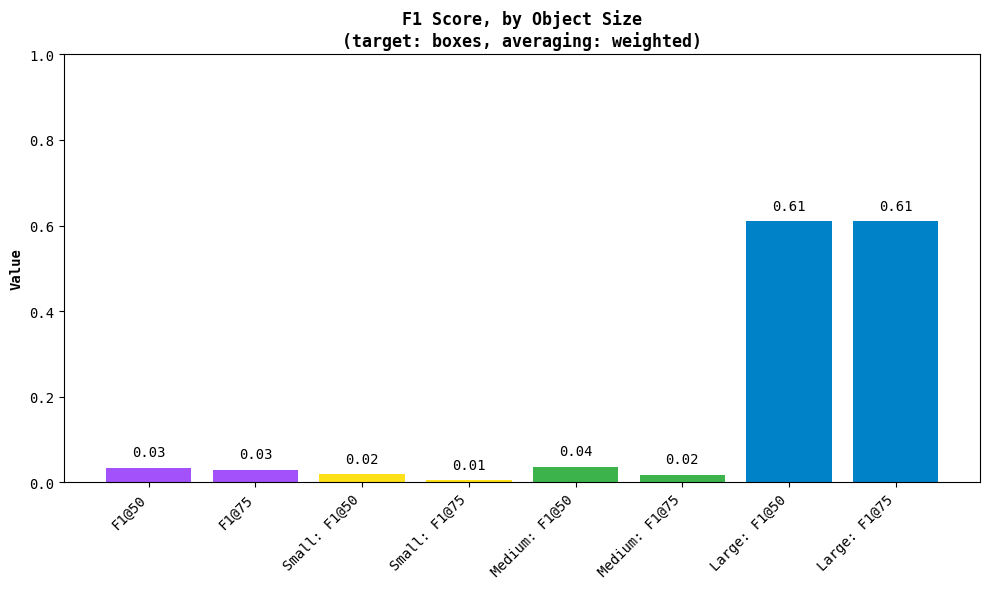

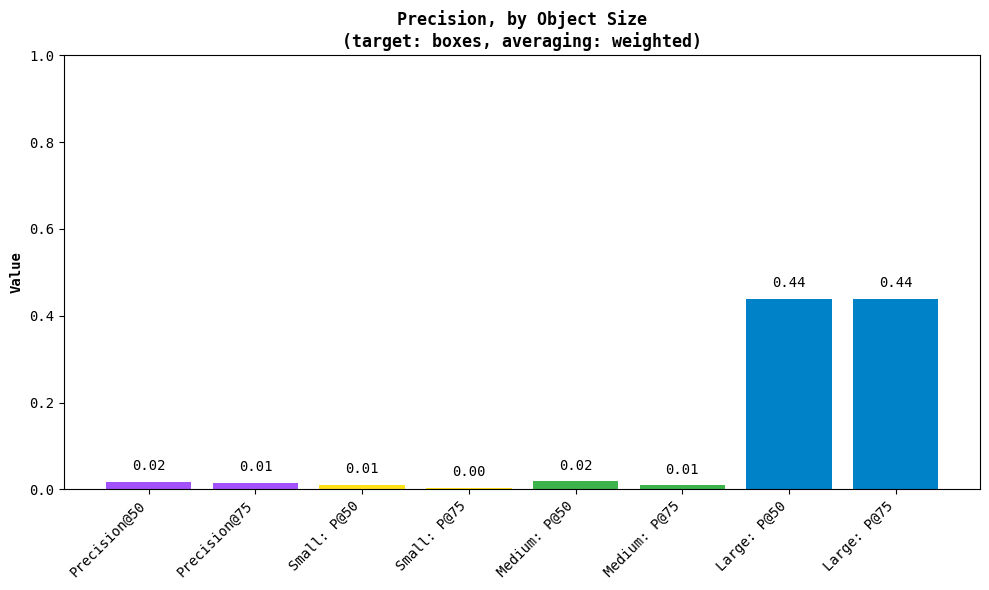

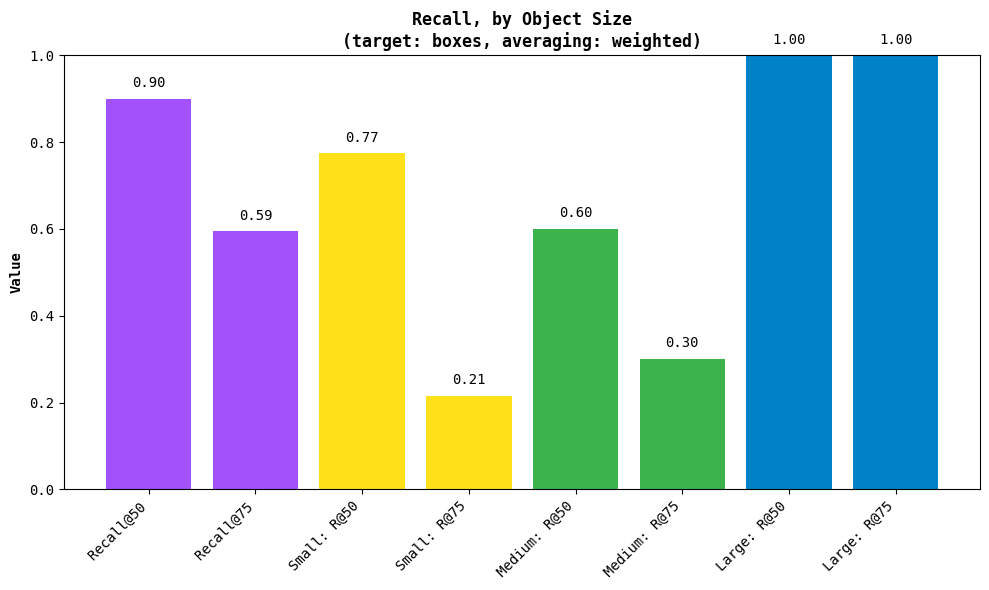

In [16]:
from supervision.metrics import F1Score, Precision, Recall

f1 = F1Score()
prec = Precision()
rec = Recall()

f1 = f1.update(predictions, targets).compute()
prec = prec.update(predictions, targets).compute()
rec = rec.update(predictions, targets).compute()

f1.plot()
prec.plot()
rec.plot()


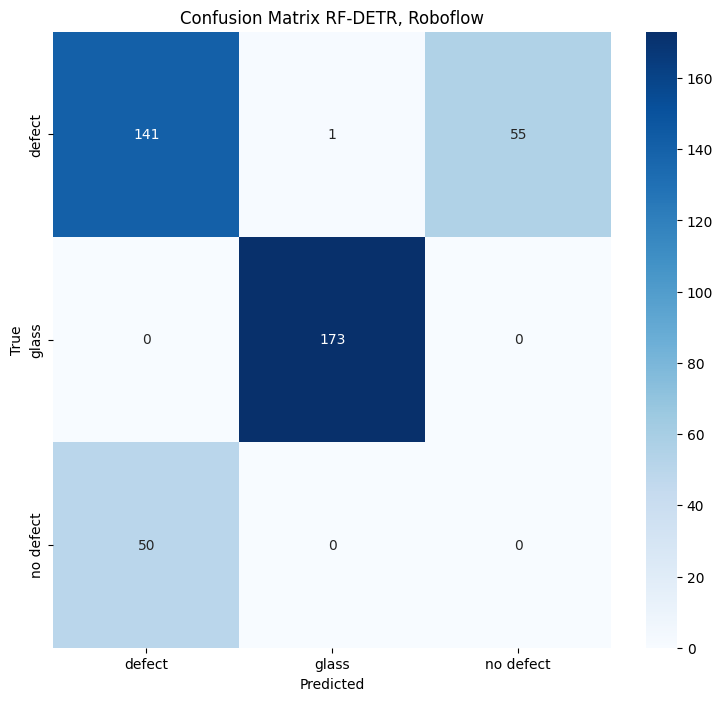


Consolidated 3x3 Matrix (True Row vs. Predicted Column):

           defect  glass  no defect
defect        141      1         55
glass           0    173          0
no defect      50      0          0


In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Construct the 3x3 Matrix Data ---
# Classes: 0=defect, 1=glass, 2=Background

# Row 0 (True: defect)
# P: defect (141), P: glass (1), P: Background (FN = 55)
row_defect = [141, 1, 55] 

# Row 1 (True: glass)
# P: defect (50), P: glass (173), P: Background (FN for glass, assumed 0)
row_glass = [0, 173, 0] 

# Row 2 (True: Background)
# P: defect (FP = 50), P: glass (FP for glass, assumed 0), P: Background (TN, assumed 0)
row_background = [50, 0, 0]

cm_3x3_data = np.array([
    row_defect, 
    row_glass, 
    row_background
])

labels_3x3 = ['defect', 'glass', 'no defect']


# --- 2. Plot the 3x3 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_3x3_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=labels_3x3,
    yticklabels=labels_3x3
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix RF-DETR, Roboflow')
plt.show()

# Print the matrix for easy reference
print("\nConsolidated 3x3 Matrix (True Row vs. Predicted Column):\n")
df = pd.DataFrame(cm_3x3_data, index=labels_3x3, columns=labels_3x3)
print(df)

In [ ]:
confusion = sv.ConfusionMatrix.from_detections(predictions, targets)